# Neural Networks - recitation

```In this short excersice, you will experience with implementing neural network for binary classification task, and check it on a real dataset.
It may give you a basic understanding about the model and it's limits, and above all, about how it works.```


```So lets start by itroduction to some notions, that will help us use "gradient descent" methods to train networks.```

```~Gild Royz```

---

## Completed implementation

### Guidelines and execution plan

1. Use the supplied scikit-learn breast-cancer dataset and verify its shape, types, missing values, class balance, and feature names before modeling.
2. Create one deterministic stratified 70% train / 15% validation / 15% test split. Fit preprocessing on training data only and leave the test set untouched until final evaluation.
3. Implement ReLU, sigmoid, binary cross-entropy, forward propagation, scalar-loop back-propagation, and vectorized back-propagation from first principles with NumPy/SciPy.
4. Test activation and loss derivatives numerically. Test scalar and vectorized network gradients against each other from identical inputs and parameters.
5. Train the scalar and vectorized implementations from the same initialization and with the same shuffled mini-batches so runtime and numerical comparisons are fair.
6. Train a modern Keras reference model with the same 30–10–1 architecture. Use validation AUC for model comparison, then report held-out accuracy, balanced accuracy, AUC, loss, ROC curves, and confusion matrices.
7. Use deterministic seeds, meaningful names, keyword arguments where APIs permit them, explicit type annotations, and failures that raise immediately.
8. Save figures and structured metrics to a timestamped output directory, then export a visually checked Excel workbook.
9. Quality gates: derivative relative error <= 1e-5; scalar/vectorized gradient difference <= 1e-10; manual test AUC >= 0.98; manual test accuracy and balanced accuracy >= 0.93; Keras test AUC >= 0.98 and balanced accuracy >= 0.93; vectorized predictions match scalar predictions within 1e-8; vectorized training is faster than scalar training.

## Scope and hardware strategy

This recitation builds a binary classifier twice from first principles and once with Keras. The machine has an Intel Core Ultra 7 165H (16 cores / 22 threads), about 63 GB RAM, and integrated Intel Arc Pro graphics. Native Windows TensorFlow does not expose a supported CUDA device, but this dataset has only 569 rows and 30 features, so CPU/oneDNN execution is more than sufficient. Vectorized NumPy operations are the important optimization here; GPU setup would add overhead without a meaningful speed benefit.

> **Original recitation instructions**

## Chain rule

for a given functions, h,f,g such that:

$$h(x) = f(g(x))$$

we know that:

$$\frac{dh}{dx} = \frac{df}{dg} \cdot \frac{dg}{dx}$$

For example:

$f(x) = x^2$

$g(x) = 2x + 5$

$h(x) = f(g(x))$

$$\frac{dh}{dx} = 2(2x + 5) \cdot 2 = 8x + 20$$

## Chain rule

For h(x) = f(g(x)), the derivative is the product of the local derivatives:

dh/dx = (df/dg) * (dg/dx).

Example: if f(z) = z² and g(x) = 2x + 5, then h(x) = (2x + 5)² and

dh/dx = 2(2x + 5) * 2 = 8x + 20.

Back-propagation applies this rule repeatedly from the loss toward the earliest parameters.

> **Original recitation instructions**

## Functions as computational graphs

Every function can be writen as a computational acyclic graph, where the nodes are the variables, and the egdes are the actions. Example:

$$f(x) = x^2 + 5x^3$$

Its computation graph is:

```text
x ──► h=x² ─────────────┐
                         ├──► p=h+s ──► f=p
x ──► q=x³ ──► s=5q ───┘
```

Ok cool. how is it helping us?
Lets try to calculate  $\frac{\partial}{\partial x}f$  and see what we get:

($\frac{\partial}{\partial x}f$ stands for deriving f according to x)

$$\frac{\partial}{\partial x}f = 2x + 15x^2$$

But because that f is composed of several functions, we can write it as follow:

$$f(x) = f(p(h(x), s(q(x))))$$

if we will derive the function according to the chan rule, we will get:

$$\frac{\partial f}{\partial x} = \frac{\partial f}{\partial p} \cdot \frac{\partial p}{\partial x} = \frac{\partial f}{\partial p} \cdot (\frac{\partial p}{\partial h} \cdot  \frac{\partial h}{\partial x} + \frac{\partial p}{\partial s} \cdot  \frac{\partial s}{\partial x}) = \frac{\partial f}{\partial p} \cdot (\frac{\partial p}{\partial h} \cdot  \frac{\partial h}{\partial x} + \frac{\partial p}{\partial s} \cdot  \frac{\partial s}{\partial q} \cdot \frac{\partial q}{\partial x}) = 1 \cdot (1 \cdot 2x + 1 \cdot 5 \cdot 3x^2) = 2x + 15x^2$$

We can conclude from here, that the derivation of a node u, according to earlier node v, is the sum of derivations of all paths between v -> u.

## Functions as computational graphs

A differentiable program can be represented as a directed acyclic graph whose nodes hold intermediate values and whose edges are operations. For

f(x) = x² + 5x³,

the derivative is

df/dx = 2x + 15x².

When several graph paths connect an earlier value to the output, their gradient contributions add. Along each individual path, local derivatives multiply. Neural-network back-propagation is an efficient reverse traversal that reuses these intermediate derivatives rather than recomputing every path independently.
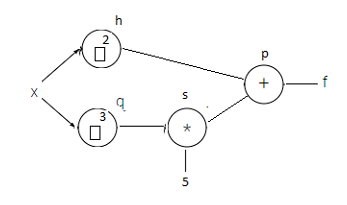

In [1]:
from __future__ import annotations

from collections.abc import Callable
from dataclasses import dataclass
from time import perf_counter
from typing import Any
import json
import os

from neural_network_recitation_init import (
    LOGGER,
    OUTPUT_DIRECTORY,
    RANDOM_SEED,
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import Markdown, display
from scipy.special import expit
from sklearn import datasets
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

tf.config.threading.set_intra_op_parallelism_threads(
    num_threads=min(os.cpu_count() or 1, 16)
)
tf.config.threading.set_inter_op_parallelism_threads(num_threads=2)
keras.utils.set_random_seed(seed=RANDOM_SEED)
tf.config.experimental.enable_op_determinism()

METRIC_RECORDS: list[dict[str, Any]] = []
TIMING_RECORDS: list[dict[str, Any]] = []
FIGURE_PATHS: list[str] = []

LOGGER.info("TensorFlow %s; Keras %s", tf.__version__, keras.__version__)
LOGGER.info("Logical devices: %s", [device.name for device in tf.config.list_logical_devices()])
LOGGER.info("CPU threads: %s; execution strategy: CPU/oneDNN and vectorized NumPy", os.cpu_count())

2026-09-06 18:13:02,526 | INFO | neural_network_recitation | Output directory: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\recitation\outputs\neural_network_recitation_20260906_181302
2026-09-06 18:13:10,125 | INFO | neural_network_recitation | TensorFlow 2.21.0; Keras 3.15.1
2026-09-06 18:13:10,131 | INFO | neural_network_recitation | Logical devices: ['/device:CPU:0']
2026-09-06 18:13:10,132 | INFO | neural_network_recitation | CPU threads: 22; execution strategy: CPU/oneDNN and vectorized NumPy


In [2]:
@dataclass
class NetworkParameters:
    """Parameters for the 30–10–1 dense neural network."""

    weights_1: np.ndarray
    bias_1: np.ndarray
    weights_2: np.ndarray
    bias_2: np.ndarray


@dataclass
class ForwardPass:
    """Intermediate values retained for back-propagation."""

    hidden_pre_activation: np.ndarray
    hidden_activation: np.ndarray
    output_pre_activation: np.ndarray
    probabilities: np.ndarray


@dataclass
class TrainingResult:
    """Parameters, learning curves, and runtime from one implementation."""

    parameters: NetworkParameters
    train_losses: list[float]
    train_accuracies: list[float]
    validation_losses: list[float]
    validation_accuracies: list[float]
    elapsed_seconds: float


def save_figure(*, figure: plt.Figure, file_name: str) -> str:
    """Save and register a notebook figure.

    Args:
        figure: Matplotlib figure to save.
        file_name: Output PNG file name.

    Returns:
        Absolute output path.
    """
    figure_path = OUTPUT_DIRECTORY / file_name
    figure.savefig(
        fname=figure_path,
        dpi=160,
        bbox_inches="tight",
        facecolor="white",
    )
    absolute_path = str(figure_path.resolve())
    FIGURE_PATHS.append(absolute_path)
    LOGGER.info("Saved figure: %s", absolute_path)
    return absolute_path


def copy_parameters(*, parameters: NetworkParameters) -> NetworkParameters:
    """Deep-copy network parameter arrays.

    Args:
        parameters: Parameters to copy.

    Returns:
        Independent parameter arrays.
    """
    return NetworkParameters(
        weights_1=parameters.weights_1.copy(),
        bias_1=parameters.bias_1.copy(),
        weights_2=parameters.weights_2.copy(),
        bias_2=parameters.bias_2.copy(),
    )

> **Original recitation instructions**

We will look at the "breast cancer" dataset, and try to build a neural network that fits it.

## Breast-cancer classification data

The target is binary: malignant tumors are class 0 and benign tumors are class 1. Before training, inspect the 569 samples, 30 numeric features, missing values, and class balance. Stratification preserves that balance across train, validation, and test partitions.

In [3]:
breast_cancer_dataset = datasets.load_breast_cancer()
all_features = np.asarray(breast_cancer_dataset.data, dtype=np.float64)
all_targets = np.asarray(breast_cancer_dataset.target, dtype=np.int64)
feature_names = np.asarray(breast_cancer_dataset.feature_names, dtype=str)

dataset_summary = pd.DataFrame(
    data=[
        {
            "rows": all_features.shape[0],
            "features": all_features.shape[1],
            "missing_values": int(np.isnan(all_features).sum()),
            "malignant_rows": int(np.sum(all_targets == 0)),
            "benign_rows": int(np.sum(all_targets == 1)),
            "positive_rate": float(np.mean(all_targets)),
        }
    ]
)
display(dataset_summary)
display(
    pd.DataFrame(
        data=all_features[:5, :5],
        columns=feature_names[:5],
    ).assign(target=all_targets[:5])
)

assert all_features.shape == (569, 30)
assert all_targets.shape == (569,)
assert np.isfinite(all_features).all()
assert set(np.unique(all_targets).tolist()) == {0, 1}

,rows,features,missing_values,malignant_rows,benign_rows,positive_rate
0,569,30,0,212,357,0.627417


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,target
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [4]:
outer_splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=RANDOM_SEED,
)
train_indices, holdout_indices = next(
    outer_splitter.split(
        X=all_features,
        y=all_targets,
    )
)
holdout_features = all_features[holdout_indices]
holdout_targets = all_targets[holdout_indices]

inner_splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=RANDOM_SEED + 1,
)
validation_relative_indices, test_relative_indices = next(
    inner_splitter.split(
        X=holdout_features,
        y=holdout_targets,
    )
)

train_features_raw = all_features[train_indices]
train_targets = all_targets[train_indices]
validation_features_raw = holdout_features[validation_relative_indices]
validation_targets = holdout_targets[validation_relative_indices]
test_features_raw = holdout_features[test_relative_indices]
test_targets = holdout_targets[test_relative_indices]

split_summary = pd.DataFrame(
    data=[
        {
            "partition": partition_name,
            "rows": partition_targets.size,
            "positive_rate": float(np.mean(partition_targets)),
        }
        for partition_name, partition_targets in (
            ("train", train_targets),
            ("validation", validation_targets),
            ("test", test_targets),
        )
    ]
)
display(split_summary)
assert train_targets.size + validation_targets.size + test_targets.size == 569
assert set(train_indices).isdisjoint(set(holdout_indices))
LOGGER.info(
    "Split sizes | train %d | validation %d | test %d",
    train_targets.size,
    validation_targets.size,
    test_targets.size,
)

,partition,rows,positive_rate
0,train,398,0.628141
1,validation,85,0.623529
2,test,86,0.627907


2026-09-06 18:13:10,356 | INFO | neural_network_recitation | Split sizes | train 398 | validation 85 | test 86


> **Original recitation instructions**

Lets Normalize the data to have "mean 0" and "standard deviation 1", in order to help the network deal with it.

## Leakage-safe standardization

Feature scales vary by several orders of magnitude. Fit `StandardScaler` only on the training partition, then apply the stored training mean and standard deviation to validation and test data. This prevents validation or test statistics from leaking into the fitted model.

2026-09-06 18:13:10,519 | INFO | neural_network_recitation | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\recitation\outputs\neural_network_recitation_20260906_181302\class_distribution.png


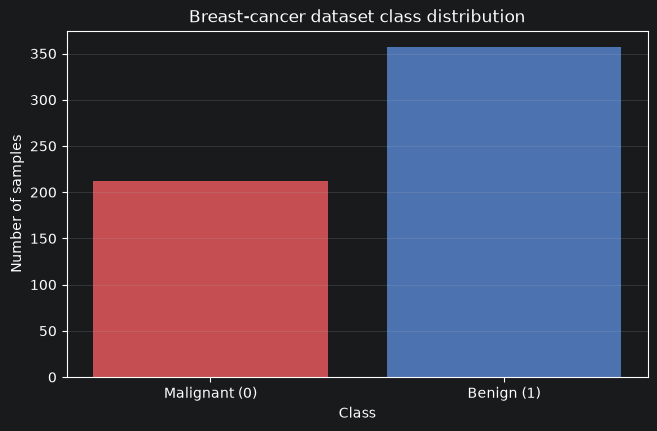

In [5]:
feature_scaler = StandardScaler(
    copy=True,
    with_mean=True,
    with_std=True,
)
train_features = feature_scaler.fit_transform(X=train_features_raw)
validation_features = feature_scaler.transform(X=validation_features_raw)
test_features = feature_scaler.transform(X=test_features_raw)

assert train_features.shape[1] == 30
assert np.allclose(
    a=np.mean(train_features, axis=0),
    b=np.zeros(30),
    atol=1e-12,
)
assert np.isfinite(validation_features).all()
assert np.isfinite(test_features).all()

class_distribution_figure, class_distribution_axis = plt.subplots(
    figsize=(7.5, 4.5)
)
class_counts = np.bincount(all_targets, minlength=2)
class_distribution_axis.bar(
    x=["Malignant (0)", "Benign (1)"],
    height=class_counts,
    color=["#C44E52", "#4C72B0"],
)
class_distribution_axis.set(
    title="Breast-cancer dataset class distribution",
    xlabel="Class",
    ylabel="Number of samples",
)
class_distribution_axis.grid(visible=True, axis="y", alpha=0.25)
save_figure(
    figure=class_distribution_figure,
    file_name="class_distribution.png",
)
plt.show()

In [6]:
keras.utils.set_random_seed(seed=RANDOM_SEED + 100)
keras_input = keras.Input(shape=(30,), name="features")
keras_hidden = keras.layers.Dense(
    units=10,
    activation="relu",
    kernel_initializer=keras.initializers.HeNormal(seed=RANDOM_SEED + 101),
    name="hidden_relu",
)(keras_input)
keras_output = keras.layers.Dense(
    units=1,
    activation="sigmoid",
    kernel_initializer=keras.initializers.GlorotUniform(seed=RANDOM_SEED + 102),
    name="benign_probability",
)(keras_hidden)
keras_reference_model = keras.Model(
    inputs=keras_input,
    outputs=keras_output,
    name="breast_cancer_reference",
)
keras_reference_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc"),
    ],
)
keras_reference_model.summary(print_fn=LOGGER.info)

keras_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=20,
    min_delta=1e-4,
    restore_best_weights=True,
)
keras_training_start = perf_counter()
keras_history = keras_reference_model.fit(
    x=train_features,
    y=train_targets,
    validation_data=(validation_features, validation_targets),
    batch_size=32,
    epochs=250,
    callbacks=[keras_early_stopping],
    verbose=0,
    shuffle=True,
)
keras_elapsed_seconds = perf_counter() - keras_training_start
LOGGER.info(
    "Keras reference trained for %d epochs in %.3fs; best validation AUC %.6f",
    len(keras_history.history["loss"]),
    keras_elapsed_seconds,
    float(np.max(a=np.asarray(keras_history.history["val_auc"]))),
)

2026-09-06 18:13:10,670 | WARNING | tensorflow | TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


2026-09-06 18:13:10,682 | INFO | neural_network_recitation | Model: "breast_cancer_reference"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_relu (Dense)             │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ benign_probability (Dense)      │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 321 (1.25 KB)
 Trainable params: 321 (1.25 KB)
 Non-trainable params: 0 (0.00 B)

2026-09-06 18:13:21,418 | INFO | neural_network_recitation | Keras reference trained for 70 epochs in 10.734s; best 

> **Original recitation instructions**

### Relu activation

$$relu(x) = \begin{cases} x, \hspace{1cm} x \geq 0 \\ 0, \hspace{1cm} otherwize \end{cases}$$

$$\frac{d}{dx} relu = \begin{cases} 1, \hspace{1cm} x \geq 0 \\ 0, \hspace{1cm} otherwize \end{cases}$$

### ReLU activation

ReLU(x) = max(x, 0). Its derivative is 1 for positive inputs and 0 for negative inputs. At exactly zero the mathematical derivative is undefined; this implementation consistently uses 0, matching the usual deep-learning convention.

In [7]:
def relu(*, inputs: np.ndarray) -> np.ndarray:
    """Apply the rectified linear unit elementwise.

    Args:
        inputs: Numeric input array.

    Returns:
        Array with negative values replaced by zero.
    """
    return np.maximum(inputs, 0.0)


def relu_derivative(*, inputs: np.ndarray) -> np.ndarray:
    """Evaluate the selected ReLU subgradient.

    Args:
        inputs: Pre-activation input array.

    Returns:
        One for positive inputs and zero otherwise.
    """
    return (inputs > 0.0).astype(np.float64)


relu_test_inputs = np.asarray([-2.0, 0.0, 3.0], dtype=np.float64)
assert np.array_equal(
    relu(inputs=relu_test_inputs),
    np.asarray([0.0, 0.0, 3.0]),
)
assert np.array_equal(
    relu_derivative(inputs=relu_test_inputs),
    np.asarray([0.0, 0.0, 1.0]),
)

> **Original recitation instructions**

### Sigmoid activation

$$sigmoid(x) = \frac{1}{1 + e^{-x}}$$

$$\frac{d}{dx} sigmoid = sigmoid(x) \cdot (1 - sigmoid(x))$$

### Sigmoid activation

Sigmoid(x) = 1 / (1 + exp(-x)), with derivative sigmoid(x) * (1 - sigmoid(x)). SciPy's stable `expit` implementation avoids overflow for large-magnitude inputs.

In [8]:
def sigmoid(*, inputs: np.ndarray) -> np.ndarray:
    """Apply a numerically stable sigmoid elementwise.

    Args:
        inputs: Numeric input array.

    Returns:
        Probabilities in the closed interval from zero to one.
    """
    return expit(inputs)


def sigmoid_derivative(*, inputs: np.ndarray) -> np.ndarray:
    """Evaluate the sigmoid derivative.

    Args:
        inputs: Sigmoid pre-activation values.

    Returns:
        Elementwise sigmoid derivative.
    """
    probabilities = sigmoid(inputs=inputs)
    return probabilities * (1.0 - probabilities)


sigmoid_test_inputs = np.asarray([-2.0, -0.5, 0.5, 2.0], dtype=np.float64)
finite_difference_step = 1e-6
sigmoid_numeric_derivative = (
    sigmoid(inputs=sigmoid_test_inputs + finite_difference_step)
    - sigmoid(inputs=sigmoid_test_inputs - finite_difference_step)
) / (2.0 * finite_difference_step)
sigmoid_analytic_derivative = sigmoid_derivative(inputs=sigmoid_test_inputs)
sigmoid_derivative_maximum_error = float(
    np.max(a=np.abs(sigmoid_numeric_derivative - sigmoid_analytic_derivative))
)
assert sigmoid_derivative_maximum_error <= 1e-8

> **Original recitation instructions**

### Cross entropy

$y \in {0,1}$ - true label,  $\hspace{1cm}$  $\hat{y} \in [0,1]$ - predicted label

$$cross-entropy(y,\hat{y}) = - y * log(\hat{y}) - (1 - y) * log(1 - \hat{y})$$

When y is 0, we get punish if y_hat is bigger then 0.

When when y is 1 we get punish if y_hat is smaller then 1.

and the derivative according to $\hat{y}$ is:

$$\frac{d}{d \hat{y}}cross-entropy(y,\hat{y}) = - \frac{y}{\hat{y}} + \frac{(1 - y)}{1 - \hat{y}}$$

### Binary cross-entropy

For target y in {0, 1} and predicted probability p in [0, 1],

BCE(y, p) = -y log(p) - (1-y) log(1-p),

and dBCE/dp = -y/p + (1-y)/(1-p).

Clipping probabilities prevents log(0) and division by zero. When BCE is paired with a sigmoid output, the chain rule simplifies the logit derivative to p-y, which is both faster and numerically more stable.

In [9]:
def binary_cross_entropy(
    *,
    targets: np.ndarray,
    probabilities: np.ndarray,
    epsilon: float = 1e-12,
) -> np.ndarray:
    """Compute elementwise binary cross-entropy.

    Args:
        targets: Binary labels.
        probabilities: Predicted positive-class probabilities.
        epsilon: Clipping distance from zero and one.

    Returns:
        Elementwise loss values.
    """
    clipped_probabilities = np.clip(
        a=probabilities,
        a_min=epsilon,
        a_max=1.0 - epsilon,
    )
    return -(
        targets * np.log(clipped_probabilities)
        + (1.0 - targets) * np.log(1.0 - clipped_probabilities)
    )


def binary_cross_entropy_derivative(
    *,
    targets: np.ndarray,
    probabilities: np.ndarray,
    epsilon: float = 1e-12,
) -> np.ndarray:
    """Differentiate BCE with respect to probability.

    Args:
        targets: Binary labels.
        probabilities: Predicted positive-class probabilities.
        epsilon: Clipping distance from zero and one.

    Returns:
        Elementwise derivative values.
    """
    clipped_probabilities = np.clip(
        a=probabilities,
        a_min=epsilon,
        a_max=1.0 - epsilon,
    )
    return (
        -targets / clipped_probabilities
        + (1.0 - targets) / (1.0 - clipped_probabilities)
    )


bce_test_targets = np.asarray([0.0, 1.0], dtype=np.float64)
bce_test_probabilities = np.asarray([0.25, 0.75], dtype=np.float64)
bce_numeric_derivative = (
    binary_cross_entropy(
        targets=bce_test_targets,
        probabilities=bce_test_probabilities + finite_difference_step,
    )
    - binary_cross_entropy(
        targets=bce_test_targets,
        probabilities=bce_test_probabilities - finite_difference_step,
    )
) / (2.0 * finite_difference_step)
bce_analytic_derivative = binary_cross_entropy_derivative(
    targets=bce_test_targets,
    probabilities=bce_test_probabilities,
)
bce_derivative_maximum_error = float(
    np.max(a=np.abs(bce_numeric_derivative - bce_analytic_derivative))
)
assert bce_derivative_maximum_error <= 1e-6

> **Original recitation instructions**

## Architecture

We will do a 2-layer fully connected NN with the following details:

- First layer  - 10 neurons with "relu" activation.
- Second layer - 1 neurons with "sigmoid" activation.
- Loss         - "binary crossentropy"

```text
30 inputs → Dense(10, ReLU) → Dense(1, sigmoid)
```

## Network architecture

The manual classifier has two Dense layers:

- Input: 30 standardized measurements.
- Hidden layer: 10 neurons with ReLU activation.
- Output layer: one sigmoid probability for the benign class.
- Objective: mean binary cross-entropy.
- Optimizer: mini-batch gradient descent implemented directly with NumPy.

For a feature matrix X arranged as features by samples:

A = W1 X + b1

H = ReLU(A)

Z = W2 H + b2

P = sigmoid(Z).
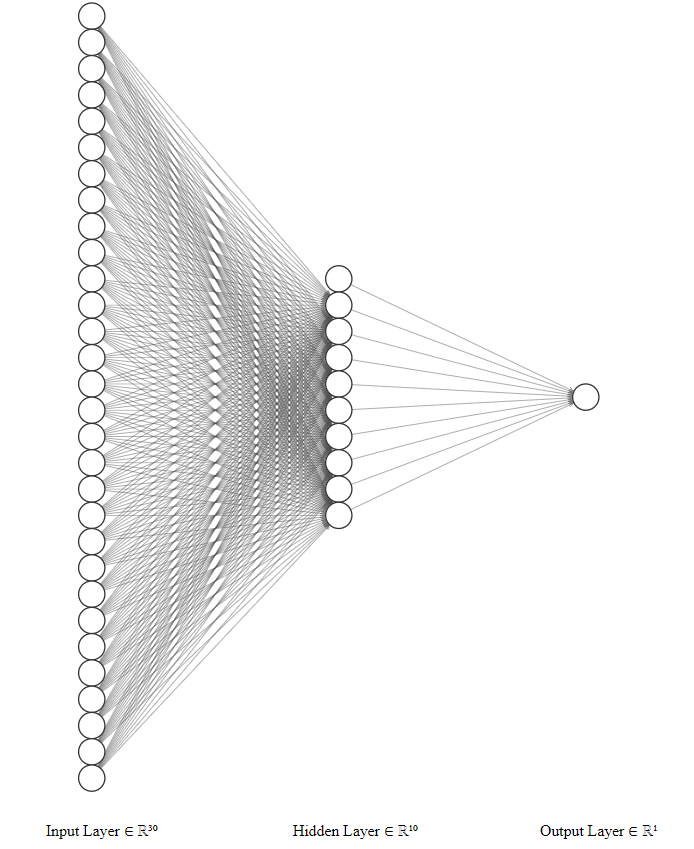

In [10]:
def initialize_parameters(
    *,
    number_of_input_features: int = 30,
    number_of_hidden_units: int = 10,
    seed: int = RANDOM_SEED,
) -> NetworkParameters:
    """Initialize the 30–10–1 network with He-scaled weights.

    Args:
        number_of_input_features: Number of input features.
        number_of_hidden_units: Number of ReLU hidden units.
        seed: Random initialization seed.

    Returns:
        Initialized network parameters.
    """
    random_generator = np.random.default_rng(seed=seed)
    return NetworkParameters(
        weights_1=random_generator.standard_normal(
            size=(number_of_hidden_units, number_of_input_features)
        )
        * np.sqrt(2.0 / number_of_input_features),
        bias_1=np.zeros((number_of_hidden_units, 1), dtype=np.float64),
        weights_2=random_generator.standard_normal(
            size=(1, number_of_hidden_units)
        )
        * np.sqrt(2.0 / number_of_hidden_units),
        bias_2=np.zeros((1, 1), dtype=np.float64),
    )


def predict_full(
    *,
    features_by_sample: np.ndarray,
    parameters: NetworkParameters,
) -> ForwardPass:
    """Run forward propagation and retain intermediate arrays.

    Args:
        features_by_sample: Standardized features shaped features by samples.
        parameters: Current network parameters.

    Returns:
        Forward-pass intermediate arrays.
    """
    hidden_pre_activation = (
        parameters.weights_1 @ features_by_sample + parameters.bias_1
    )
    hidden_activation = relu(inputs=hidden_pre_activation)
    output_pre_activation = (
        parameters.weights_2 @ hidden_activation + parameters.bias_2
    )
    probabilities = sigmoid(inputs=output_pre_activation)
    return ForwardPass(
        hidden_pre_activation=hidden_pre_activation,
        hidden_activation=hidden_activation,
        output_pre_activation=output_pre_activation,
        probabilities=probabilities,
    )


def predict(
    *,
    features_by_sample: np.ndarray,
    parameters: NetworkParameters,
) -> np.ndarray:
    """Predict positive-class probabilities.

    Args:
        features_by_sample: Standardized features shaped features by samples.
        parameters: Current network parameters.

    Returns:
        One probability per sample.
    """
    return predict_full(
        features_by_sample=features_by_sample,
        parameters=parameters,
    ).probabilities


forward_test_parameters = initialize_parameters(seed=RANDOM_SEED)
forward_test_result = predict_full(
    features_by_sample=train_features[:4].T,
    parameters=forward_test_parameters,
)
assert forward_test_result.hidden_activation.shape == (10, 4)
assert forward_test_result.probabilities.shape == (1, 4)
assert np.logical_and(
    forward_test_result.probabilities >= 0.0,
    forward_test_result.probabilities <= 1.0,
).all()

In [11]:
def plot_training_process(
    *,
    train_losses: list[float],
    train_accuracies: list[float],
    validation_losses: list[float],
    validation_accuracies: list[float],
    title_prefix: str,
) -> plt.Figure:
    """Plot loss and accuracy learning curves.

    Args:
        train_losses: Per-epoch training BCE.
        train_accuracies: Per-epoch training accuracy.
        validation_losses: Per-epoch validation BCE.
        validation_accuracies: Per-epoch validation accuracy.
        title_prefix: Label identifying the implementation.

    Returns:
        Matplotlib figure containing both curves.
    """
    epoch_numbers = np.arange(start=1, stop=len(train_losses) + 1)
    figure, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(11, 4.5),
    )
    axes[0].scatter(
        x=epoch_numbers,
        y=train_losses,
        s=9,
        alpha=0.75,
        label="train",
    )
    axes[0].scatter(
        x=epoch_numbers,
        y=validation_losses,
        s=9,
        alpha=0.75,
        label="validation",
    )
    axes[0].set(
        title=f"{title_prefix} loss",
        xlabel="Epoch",
        ylabel="Binary cross-entropy",
    )
    axes[0].legend()
    axes[0].grid(visible=True, alpha=0.25)

    axes[1].scatter(
        x=epoch_numbers,
        y=train_accuracies,
        s=9,
        alpha=0.75,
        label="train",
    )
    axes[1].scatter(
        x=epoch_numbers,
        y=validation_accuracies,
        s=9,
        alpha=0.75,
        label="validation",
    )
    axes[1].set(
        title=f"{title_prefix} accuracy",
        xlabel="Epoch",
        ylabel="Accuracy",
    )
    axes[1].legend()
    axes[1].grid(visible=True, alpha=0.25)
    return figure

> **Original recitation instructions**

## Implementation of the network

The network function is can be writen as follow:

for a vector x with shape (30 x 1) (with corresponding y with value {0,1}) we have:

$$f(x) = sigmoid(w^{(2)} \cdot relu(w^{(1)} \cdot x + u^{(1)}) + u^{(2)})$$
$$loss(x,y) = cross-entropy(y, f(x))$$

where:
- $w^{(1)}$ is a weight matrix with shape (10,30)
- $u^{(1)}$ is a bias vector with shape (10,1)


- $w^{(2)}$ is a weight matrix with shape (1,10)
- $u^{(2)}$ is a bias vector with shape (1,1)

according to the chain rule, we can calculate the derivatives of: $w^{(1)}, u^{(1)}, w^{(2)}, u^{(2)}$

First lets make some markings that will make our life easer:

$a = w^{(1)} \cdot x + u^{(1)}$ (shape: 10 x 1)

$a^{(z)} = relu(a)$ (output of layer 1) (shape: 10 x 1)

$b = w^{(2)} \cdot a^{(z)} + u^{(2)}$ (shape: 1 x 1)

$b^{(z)} = sigmoid(b)$ (the network output) (shape: 1 x 1)

$loss(x,y) = cross-entropy(y, b^{(z)})$

$$\frac{\partial loss}{\partial w^{(2)}_{0,k}} = \frac{\partial loss}{\partial b^{(z)}} \cdot \frac{\partial b^{(z)}}{\partial b} \cdot \frac{\partial b}{\partial w^{(2)}_{0,k}}$$

$$\frac{\partial loss}{\partial u^{(2)}_{0,0}} = \frac{\partial loss}{\partial b^{(z)}} \cdot \frac{\partial b^{(z)}}{\partial b} \cdot \frac{\partial b}{\partial u^{(2)}_{0,0}}$$

$$\frac{\partial loss}{\partial w^{(1)}_{k,j}} = \frac{\partial loss}{\partial b^{(z)}} \cdot \frac{\partial b^{(z)}}{\partial b} \cdot \frac{\partial b}{\partial a^{(z)}_k} \cdot \frac{\partial a^{(z)}_k}{\partial a_k} \cdot \frac{\partial a_k}{\partial w^{(1)}_{k,j}}$$

$$\frac{\partial loss}{\partial u^{(1)}_{k,0}} = \frac{\partial loss}{\partial b^{(z)}} \cdot \frac{\partial b^{(z)}}{\partial b} \cdot \frac{\partial b}{\partial a^{(z)}_k} \cdot \frac{\partial a^{(z)}_k}{\partial a_k} \cdot \frac{\partial a_k}{\partial u^{(1)}_{k,0}}$$

## Back-propagation implementation

For one sample, the sigmoid-plus-BCE output delta simplifies to

delta2 = probability - target.

The second-layer gradients are delta2 times the hidden activations for W2 and delta2 for b2. Propagating through the hidden layer gives

delta1 = (W2 transposed times delta2) elementwise-multiplied by ReLU'(A).

The first-layer gradients are delta1 times the input for W1 and delta1 for b1. The scalar implementation below accumulates these terms one sample at a time. The bonus implementation performs the same algebra with matrix multiplication over a full mini-batch.

In [12]:
def compute_scalar_gradients(
    *,
    features_by_sample: np.ndarray,
    targets_by_sample: np.ndarray,
    parameters: NetworkParameters,
) -> NetworkParameters:
    """Compute mini-batch gradients with explicit sample loops.

    Args:
        features_by_sample: Batch shaped features by samples.
        targets_by_sample: Batch labels shaped one by samples.
        parameters: Current network parameters.

    Returns:
        Mean gradients matching the parameter shapes.
    """
    forward_pass = predict_full(
        features_by_sample=features_by_sample,
        parameters=parameters,
    )
    number_of_batch_samples = targets_by_sample.shape[1]
    gradients = NetworkParameters(
        weights_1=np.zeros_like(a=parameters.weights_1),
        bias_1=np.zeros_like(a=parameters.bias_1),
        weights_2=np.zeros_like(a=parameters.weights_2),
        bias_2=np.zeros_like(a=parameters.bias_2),
    )

    for sample_number in range(number_of_batch_samples):
        output_delta = float(
            forward_pass.probabilities[0, sample_number]
            - targets_by_sample[0, sample_number]
        )
        gradients.weights_2 += (
            output_delta
            * forward_pass.hidden_activation[:, sample_number].reshape((1, -1))
        )
        gradients.bias_2[0, 0] += output_delta
        hidden_delta = (
            parameters.weights_2.reshape((-1,))
            * output_delta
            * relu_derivative(
                inputs=forward_pass.hidden_pre_activation[:, sample_number]
            )
        )
        gradients.weights_1 += np.outer(
            a=hidden_delta,
            b=features_by_sample[:, sample_number],
        )
        gradients.bias_1[:, 0] += hidden_delta

    return NetworkParameters(
        weights_1=gradients.weights_1 / number_of_batch_samples,
        bias_1=gradients.bias_1 / number_of_batch_samples,
        weights_2=gradients.weights_2 / number_of_batch_samples,
        bias_2=gradients.bias_2 / number_of_batch_samples,
    )


def train_network(
    *,
    train_features_input: np.ndarray,
    train_targets_input: np.ndarray,
    validation_features_input: np.ndarray,
    validation_targets_input: np.ndarray,
    initial_parameters: NetworkParameters,
    batch_orders: np.ndarray,
    gradient_function: Callable[..., NetworkParameters],
    batch_size: int,
    learning_rate: float,
) -> TrainingResult:
    """Train the manual network with a supplied gradient implementation.

    Args:
        train_features_input: Row-major training features.
        train_targets_input: Training labels.
        validation_features_input: Row-major validation features.
        validation_targets_input: Validation labels.
        initial_parameters: Shared starting parameters.
        batch_orders: One row of shuffled training indices per epoch.
        gradient_function: Scalar or vectorized batch-gradient function.
        batch_size: Mini-batch size.
        learning_rate: Gradient-descent step size.

    Returns:
        Trained parameters, learning curves, and elapsed time.
    """
    parameters = copy_parameters(parameters=initial_parameters)
    train_features_by_sample = train_features_input.T
    train_targets_by_sample = train_targets_input.reshape((1, -1))
    validation_features_by_sample = validation_features_input.T
    validation_targets_by_sample = validation_targets_input.reshape((1, -1))
    train_losses: list[float] = []
    train_accuracies: list[float] = []
    validation_losses: list[float] = []
    validation_accuracies: list[float] = []

    training_start = perf_counter()
    for epoch_number in range(batch_orders.shape[0]):
        shuffled_indices = batch_orders[epoch_number]
        for batch_start in range(
            0,
            train_targets_input.size,
            batch_size,
        ):
            batch_indices = shuffled_indices[
                batch_start : batch_start + batch_size
            ]
            batch_features = train_features_by_sample[:, batch_indices]
            batch_targets = train_targets_by_sample[:, batch_indices]
            gradients = gradient_function(
                features_by_sample=batch_features,
                targets_by_sample=batch_targets,
                parameters=parameters,
            )
            parameters.weights_1 -= learning_rate * gradients.weights_1
            parameters.bias_1 -= learning_rate * gradients.bias_1
            parameters.weights_2 -= learning_rate * gradients.weights_2
            parameters.bias_2 -= learning_rate * gradients.bias_2

        train_probabilities = predict(
            features_by_sample=train_features_by_sample,
            parameters=parameters,
        )
        validation_probabilities = predict(
            features_by_sample=validation_features_by_sample,
            parameters=parameters,
        )
        train_losses.append(
            float(
                np.mean(
                    a=binary_cross_entropy(
                        targets=train_targets_by_sample,
                        probabilities=train_probabilities,
                    )
                )
            )
        )
        validation_losses.append(
            float(
                np.mean(
                    a=binary_cross_entropy(
                        targets=validation_targets_by_sample,
                        probabilities=validation_probabilities,
                    )
                )
            )
        )
        train_accuracies.append(
            float(
                np.mean(
                    a=(train_probabilities.reshape((-1,)) >= 0.5)
                    == train_targets_input
                )
            )
        )
        validation_accuracies.append(
            float(
                np.mean(
                    a=(validation_probabilities.reshape((-1,)) >= 0.5)
                    == validation_targets_input
                )
            )
        )
        if not np.isfinite(train_losses[-1]):
            LOGGER.error("Non-finite training loss at epoch %d", epoch_number + 1)
            raise FloatingPointError("Training loss became non-finite")

    elapsed_seconds = perf_counter() - training_start
    return TrainingResult(
        parameters=parameters,
        train_losses=train_losses,
        train_accuracies=train_accuracies,
        validation_losses=validation_losses,
        validation_accuracies=validation_accuracies,
        elapsed_seconds=elapsed_seconds,
    )

2026-09-06 18:13:24,255 | INFO | neural_network_recitation | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\recitation\outputs\neural_network_recitation_20260906_181302\scalar_training_curves.png


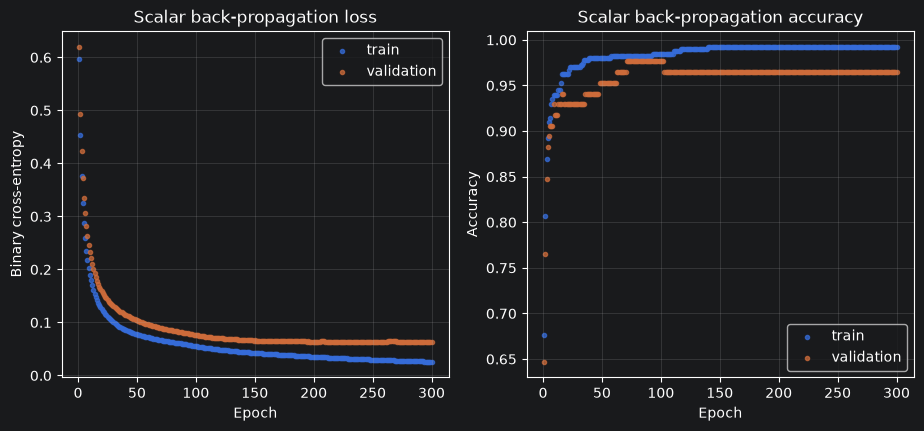

2026-09-06 18:13:24,510 | INFO | neural_network_recitation | Scalar training | 2.169s | final train loss 0.025935 | final validation loss 0.063518


In [13]:
number_of_training_epochs = 300
manual_batch_size = 32
manual_learning_rate = 0.03
shared_initial_parameters = initialize_parameters(
    number_of_input_features=30,
    number_of_hidden_units=10,
    seed=RANDOM_SEED + 200,
)
batch_order_generator = np.random.default_rng(seed=RANDOM_SEED + 201)
shared_batch_orders = np.stack(
    arrays=[
        batch_order_generator.permutation(x=train_targets.size)
        for epoch_number in range(number_of_training_epochs)
    ],
    axis=0,
)

scalar_training_result = train_network(
    train_features_input=train_features,
    train_targets_input=train_targets,
    validation_features_input=validation_features,
    validation_targets_input=validation_targets,
    initial_parameters=shared_initial_parameters,
    batch_orders=shared_batch_orders,
    gradient_function=compute_scalar_gradients,
    batch_size=manual_batch_size,
    learning_rate=manual_learning_rate,
)
scalar_training_figure = plot_training_process(
    train_losses=scalar_training_result.train_losses,
    train_accuracies=scalar_training_result.train_accuracies,
    validation_losses=scalar_training_result.validation_losses,
    validation_accuracies=scalar_training_result.validation_accuracies,
    title_prefix="Scalar back-propagation",
)
save_figure(
    figure=scalar_training_figure,
    file_name="scalar_training_curves.png",
)
plt.show()
LOGGER.info(
    "Scalar training | %.3fs | final train loss %.6f | final validation loss %.6f",
    scalar_training_result.elapsed_seconds,
    scalar_training_result.train_losses[-1],
    scalar_training_result.validation_losses[-1],
)

> **Original recitation instructions**

## Check performance

In [14]:
def display_original_classification_report(
    *,
    targets: np.ndarray,
    probabilities: np.ndarray,
) -> dict[str, Any]:
    """Display final test metrics in the original recitation format.

    Args:
        targets: Binary ground-truth labels.
        probabilities: Positive-class probabilities.

    Returns:
        Calculated metrics and the confusion matrix.
    """
    flattened_probabilities = probabilities.reshape((-1,))
    report_predictions = (flattened_probabilities >= 0.5).astype(np.int64)
    report_accuracy = float(np.mean(a=report_predictions == targets))
    report_balanced_accuracy = float(
        balanced_accuracy_score(
            y_true=targets,
            y_pred=report_predictions,
        )
    )
    report_auc = float(
        roc_auc_score(
            y_true=targets,
            y_score=flattened_probabilities,
        )
    )
    report_confusion_matrix = confusion_matrix(
        y_true=targets,
        y_pred=report_predictions,
        labels=[0, 1],
    )
    display(
        Markdown(
            f"""```text
test accuracy:	{report_accuracy:.12g}
balanced accuracy:	{report_balanced_accuracy:.12g}
auc:		{report_auc:.12g}
confussion matrix:
{report_confusion_matrix}
```"""
        )
    )
    return {
        "accuracy": report_accuracy,
        "balanced_accuracy": report_balanced_accuracy,
        "auc": report_auc,
        "confusion_matrix": report_confusion_matrix,
    }


scalar_section_test_probabilities = predict(
    features_by_sample=test_features.T,
    parameters=scalar_training_result.parameters,
)
scalar_section_test_report = display_original_classification_report(
    targets=test_targets,
    probabilities=scalar_section_test_probabilities,
)

```text
test accuracy:	0.988372093023
balanced accuracy:	0.990740740741
auc:		1
confussion matrix:
[[32  0]
 [ 1 53]]
```

## Scalar implementation validation performance

The historical scalar section above reports held-out test metrics in its original layout, with balanced accuracy added. Those values are diagnostic only: no later training choice uses them. The validation metrics below remain the basis for implementation comparison, and the final comparison repeats all test metrics consistently.

In [15]:
scalar_validation_probabilities = predict(
    features_by_sample=validation_features.T,
    parameters=scalar_training_result.parameters,
).reshape((-1,))
scalar_validation_predictions = (
    scalar_validation_probabilities >= 0.5
).astype(np.int64)
scalar_validation_accuracy = float(
    np.mean(a=scalar_validation_predictions == validation_targets)
)
scalar_validation_balanced_accuracy = float(
    balanced_accuracy_score(
        y_true=validation_targets,
        y_pred=scalar_validation_predictions,
    )
)
scalar_validation_auc = float(
    roc_auc_score(
        y_true=validation_targets,
        y_score=scalar_validation_probabilities,
    )
)
scalar_validation_loss = float(
    log_loss(
        y_true=validation_targets,
        y_pred=scalar_validation_probabilities,
        labels=[0, 1],
    )
)
display(
    pd.DataFrame(
        data=[
            {
                "implementation": "scalar",
                "validation_loss": scalar_validation_loss,
                "validation_accuracy": scalar_validation_accuracy,
                "validation_balanced_accuracy": scalar_validation_balanced_accuracy,
                "validation_auc": scalar_validation_auc,
            }
        ]
    )
)

,implementation,validation_loss,validation_accuracy,validation_balanced_accuracy,validation_auc
0,scalar,0.063518,0.964706,0.965507,0.997642


> **Original recitation instructions**

# Bonus

There is a way of calculating the gradients more efficiently (not calculating the same derivatives twice), and do it with matrix multiplications all the way.

A nice explenation can be found here:  http://neuralnetworksanddeeplearning.com/chap2.html

Try to implement it yourself!

## Bonus — vectorized back-propagation

The vectorized implementation calculates each mini-batch gradient with matrix multiplication, without recalculating identical intermediate derivatives for individual samples. Before training, it must match the scalar implementation and finite-difference estimates from the same parameter state.

In [16]:
def compute_vectorized_gradients(
    *,
    features_by_sample: np.ndarray,
    targets_by_sample: np.ndarray,
    parameters: NetworkParameters,
) -> NetworkParameters:
    """Compute all mini-batch gradients with matrix operations.

    Args:
        features_by_sample: Batch shaped features by samples.
        targets_by_sample: Batch labels shaped one by samples.
        parameters: Current network parameters.

    Returns:
        Mean gradients matching the parameter shapes.
    """
    forward_pass = predict_full(
        features_by_sample=features_by_sample,
        parameters=parameters,
    )
    number_of_batch_samples = targets_by_sample.shape[1]
    output_delta = (
        forward_pass.probabilities - targets_by_sample
    ) / number_of_batch_samples
    weights_2_gradient = output_delta @ forward_pass.hidden_activation.T
    bias_2_gradient = np.sum(
        a=output_delta,
        axis=1,
        keepdims=True,
    )
    hidden_delta = (
        parameters.weights_2.T @ output_delta
        * relu_derivative(inputs=forward_pass.hidden_pre_activation)
    )
    weights_1_gradient = hidden_delta @ features_by_sample.T
    bias_1_gradient = np.sum(
        a=hidden_delta,
        axis=1,
        keepdims=True,
    )
    return NetworkParameters(
        weights_1=weights_1_gradient,
        bias_1=bias_1_gradient,
        weights_2=weights_2_gradient,
        bias_2=bias_2_gradient,
    )


def mean_network_loss(
    *,
    features_by_sample: np.ndarray,
    targets_by_sample: np.ndarray,
    parameters: NetworkParameters,
) -> float:
    """Evaluate mean BCE for a parameter state.

    Args:
        features_by_sample: Batch shaped features by samples.
        targets_by_sample: Batch labels shaped one by samples.
        parameters: Parameter state to evaluate.

    Returns:
        Mean binary cross-entropy.
    """
    probabilities = predict(
        features_by_sample=features_by_sample,
        parameters=parameters,
    )
    return float(
        np.mean(
            a=binary_cross_entropy(
                targets=targets_by_sample,
                probabilities=probabilities,
            )
        )
    )


gradient_test_features = train_features[:13].T
gradient_test_targets = train_targets[:13].reshape((1, -1))
gradient_test_parameters = copy_parameters(
    parameters=shared_initial_parameters
)
scalar_test_gradients = compute_scalar_gradients(
    features_by_sample=gradient_test_features,
    targets_by_sample=gradient_test_targets,
    parameters=gradient_test_parameters,
)
vectorized_test_gradients = compute_vectorized_gradients(
    features_by_sample=gradient_test_features,
    targets_by_sample=gradient_test_targets,
    parameters=gradient_test_parameters,
)
gradient_component_differences = {
    parameter_name: float(
        np.max(
            a=np.abs(
                getattr(scalar_test_gradients, parameter_name)
                - getattr(vectorized_test_gradients, parameter_name)
            )
        )
    )
    for parameter_name in (
        "weights_1",
        "bias_1",
        "weights_2",
        "bias_2",
    )
}
maximum_scalar_vectorized_gradient_difference = max(
    gradient_component_differences.values()
)
assert maximum_scalar_vectorized_gradient_difference <= 1e-10

network_finite_difference_step = 1e-6
finite_difference_checks: list[dict[str, Any]] = []
for parameter_name, parameter_index in (
    ("weights_1", (0, 0)),
    ("bias_1", (0, 0)),
    ("weights_2", (0, 0)),
    ("bias_2", (0, 0)),
):
    plus_parameters = copy_parameters(parameters=gradient_test_parameters)
    minus_parameters = copy_parameters(parameters=gradient_test_parameters)
    getattr(plus_parameters, parameter_name)[parameter_index] += (
        network_finite_difference_step
    )
    getattr(minus_parameters, parameter_name)[parameter_index] -= (
        network_finite_difference_step
    )
    numerical_gradient = (
        mean_network_loss(
            features_by_sample=gradient_test_features,
            targets_by_sample=gradient_test_targets,
            parameters=plus_parameters,
        )
        - mean_network_loss(
            features_by_sample=gradient_test_features,
            targets_by_sample=gradient_test_targets,
            parameters=minus_parameters,
        )
    ) / (2.0 * network_finite_difference_step)
    analytic_gradient = float(
        getattr(vectorized_test_gradients, parameter_name)[parameter_index]
    )
    relative_error = abs(numerical_gradient - analytic_gradient) / max(
        1e-12,
        abs(numerical_gradient) + abs(analytic_gradient),
    )
    finite_difference_checks.append(
        {
            "parameter": parameter_name,
            "index": str(parameter_index),
            "numerical_gradient": numerical_gradient,
            "analytic_gradient": analytic_gradient,
            "relative_error": relative_error,
        }
    )

finite_difference_frame = pd.DataFrame(data=finite_difference_checks)
display(finite_difference_frame)
maximum_network_gradient_relative_error = float(
    finite_difference_frame["relative_error"].max()
)
assert maximum_network_gradient_relative_error <= 1e-5
LOGGER.info(
    "Gradient validation | scalar/vectorized max difference %.3e | finite-difference max relative error %.3e",
    maximum_scalar_vectorized_gradient_difference,
    maximum_network_gradient_relative_error,
)

,parameter,index,numerical_gradient,analytic_gradient,relative_error
0,weights_1,"(0, 0)",-0.061400,-0.061400,6.737839e-10
1,bias_1,"(0, 0)",-0.028411,-0.028411,1.889584e-10
2,weights_2,"(0, 0)",0.295885,0.295885,2.057249e-10
3,bias_2,"(0, 0)",-0.202252,-0.202252,3.259272e-10


2026-09-06 18:13:24,816 | INFO | neural_network_recitation | Gradient validation | scalar/vectorized max difference 1.110e-16 | finite-difference max relative error 6.738e-10


2026-09-06 18:13:25,439 | INFO | neural_network_recitation | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\recitation\outputs\neural_network_recitation_20260906_181302\vectorized_training_curves.png


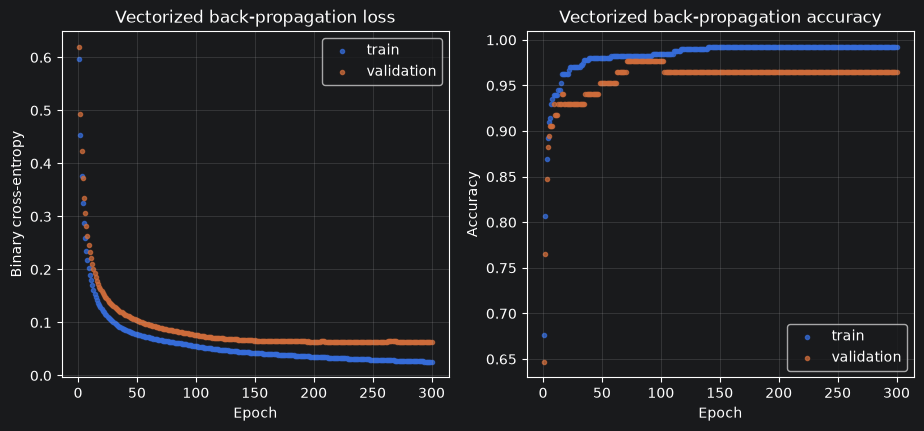

2026-09-06 18:13:25,699 | INFO | neural_network_recitation | Vectorized training | 0.219s | speedup 9.91x | prediction difference 5.551e-17


In [17]:
vectorized_training_result = train_network(
    train_features_input=train_features,
    train_targets_input=train_targets,
    validation_features_input=validation_features,
    validation_targets_input=validation_targets,
    initial_parameters=shared_initial_parameters,
    batch_orders=shared_batch_orders,
    gradient_function=compute_vectorized_gradients,
    batch_size=manual_batch_size,
    learning_rate=manual_learning_rate,
)
vectorized_training_figure = plot_training_process(
    train_losses=vectorized_training_result.train_losses,
    train_accuracies=vectorized_training_result.train_accuracies,
    validation_losses=vectorized_training_result.validation_losses,
    validation_accuracies=vectorized_training_result.validation_accuracies,
    title_prefix="Vectorized back-propagation",
)
save_figure(
    figure=vectorized_training_figure,
    file_name="vectorized_training_curves.png",
)
plt.show()

scalar_vectorized_prediction_difference = float(
    np.max(
        a=np.abs(
            predict(
                features_by_sample=validation_features.T,
                parameters=scalar_training_result.parameters,
            )
            - predict(
                features_by_sample=validation_features.T,
                parameters=vectorized_training_result.parameters,
            )
        )
    )
)
vectorized_speedup = (
    scalar_training_result.elapsed_seconds
    / vectorized_training_result.elapsed_seconds
)
LOGGER.info(
    "Vectorized training | %.3fs | speedup %.2fx | prediction difference %.3e",
    vectorized_training_result.elapsed_seconds,
    vectorized_speedup,
    scalar_vectorized_prediction_difference,
)

> **Original recitation instructions**

## Check performance

In [18]:
vectorized_section_test_probabilities = predict(
    features_by_sample=test_features.T,
    parameters=vectorized_training_result.parameters,
)
vectorized_section_test_report = display_original_classification_report(
    targets=test_targets,
    probabilities=vectorized_section_test_probabilities,
)

```text
test accuracy:	0.988372093023
balanced accuracy:	0.990740740741
auc:		1
confussion matrix:
[[32  0]
 [ 1 53]]
```

## Final model comparison

Compare validation AUC for selection, then evaluate all three implementations once on the untouched test partition. Probability-based AUC is the primary selection metric; accuracy, balanced accuracy, binary cross-entropy, confusion matrices, and ROC curves provide complementary diagnostics.

Balanced accuracy is the mean recall across the malignant and benign classes. Reporting it beside ordinary accuracy prevents the larger benign class from dominating the summary.

,implementation,partition,loss,accuracy,balanced_accuracy,auc
0,scalar,validation,0.063518,0.964706,0.965507,0.997642
1,vectorized,validation,0.063518,0.964706,0.965507,0.997642
2,keras,validation,0.090998,0.976471,0.974941,0.997052
3,scalar,test,0.028399,0.988372,0.990741,1.000000
4,vectorized,test,0.028399,0.988372,0.990741,1.000000
5,keras,test,0.064254,0.976744,0.975116,0.999421


2026-09-06 18:13:26,272 | INFO | neural_network_recitation | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\recitation\outputs\neural_network_recitation_20260906_181302\test_confusion_matrices.png


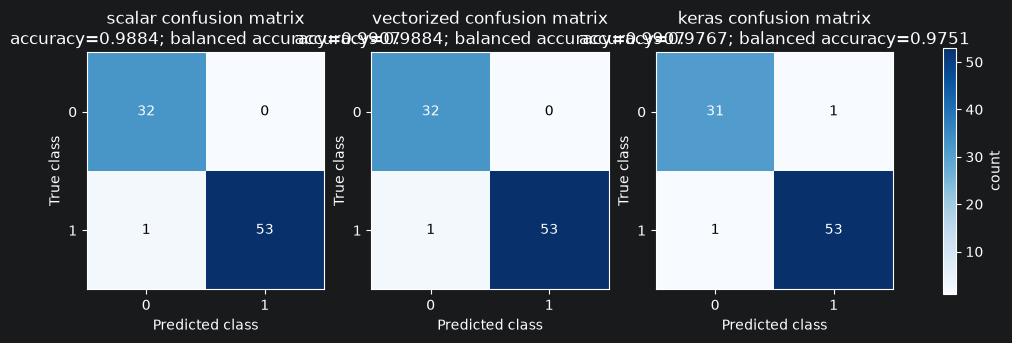

2026-09-06 18:13:26,773 | INFO | neural_network_recitation | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\recitation\outputs\neural_network_recitation_20260906_181302\test_roc_curves.png


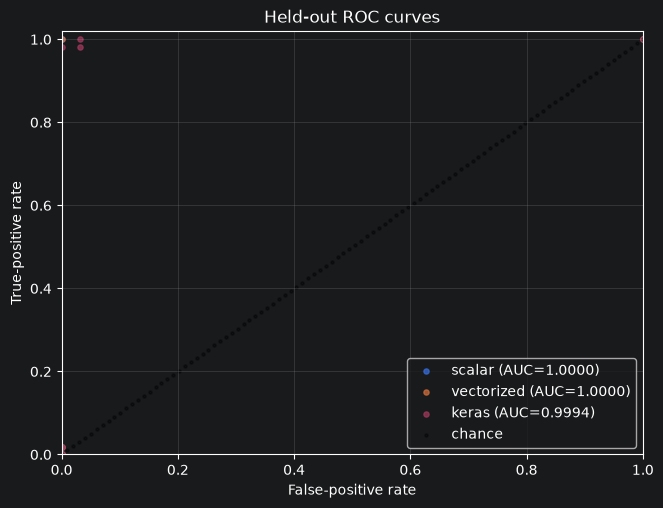

2026-09-06 18:13:27,499 | INFO | neural_network_recitation | Saved figure: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\recitation\outputs\neural_network_recitation_20260906_181302\keras_training_curves.png


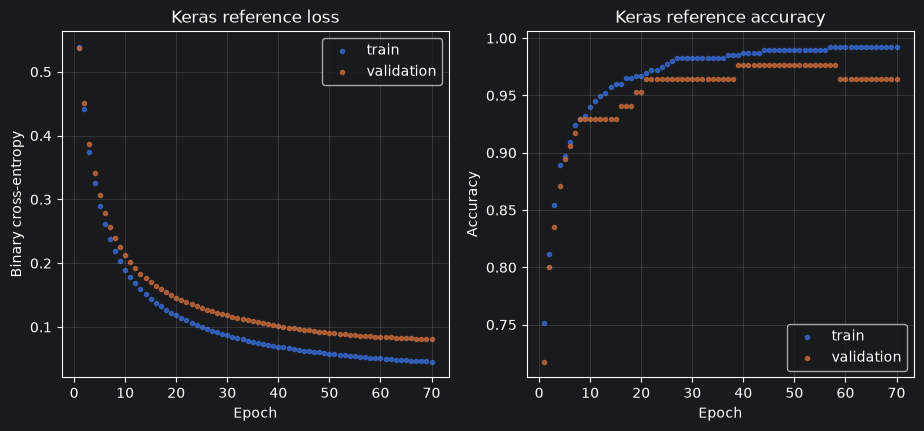

2026-09-06 18:13:27,766 | INFO | neural_network_recitation | Selected by validation AUC: vectorized (0.997642)


In [19]:
def evaluate_probabilities(
    *,
    implementation_name: str,
    targets: np.ndarray,
    probabilities: np.ndarray,
    partition_name: str,
) -> dict[str, Any]:
    """Calculate binary-classification metrics.

    Args:
        implementation_name: Model label.
        targets: Binary ground-truth labels.
        probabilities: Positive-class probabilities.
        partition_name: Validation or test label.

    Returns:
        Metric mapping including predictions and confusion matrix.
    """
    flattened_probabilities = probabilities.reshape((-1,))
    predictions = (flattened_probabilities >= 0.5).astype(np.int64)
    return {
        "implementation": implementation_name,
        "partition": partition_name,
        "loss": float(
            log_loss(
                y_true=targets,
                y_pred=flattened_probabilities,
                labels=[0, 1],
            )
        ),
        "accuracy": float(np.mean(a=predictions == targets)),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true=targets,
                y_pred=predictions,
            )
        ),
        "auc": float(
            roc_auc_score(
                y_true=targets,
                y_score=flattened_probabilities,
            )
        ),
        "probabilities": flattened_probabilities,
        "predictions": predictions,
        "confusion_matrix": confusion_matrix(
            y_true=targets,
            y_pred=predictions,
            labels=[0, 1],
        ),
    }


scalar_test_probabilities = predict(
    features_by_sample=test_features.T,
    parameters=scalar_training_result.parameters,
)
vectorized_validation_probabilities = predict(
    features_by_sample=validation_features.T,
    parameters=vectorized_training_result.parameters,
)
vectorized_test_probabilities = predict(
    features_by_sample=test_features.T,
    parameters=vectorized_training_result.parameters,
)
keras_validation_probabilities = keras_reference_model.predict(
    x=validation_features,
    batch_size=128,
    verbose=0,
)
keras_test_probabilities = keras_reference_model.predict(
    x=test_features,
    batch_size=128,
    verbose=0,
)

validation_results = [
    evaluate_probabilities(
        implementation_name="scalar",
        targets=validation_targets,
        probabilities=scalar_validation_probabilities,
        partition_name="validation",
    ),
    evaluate_probabilities(
        implementation_name="vectorized",
        targets=validation_targets,
        probabilities=vectorized_validation_probabilities,
        partition_name="validation",
    ),
    evaluate_probabilities(
        implementation_name="keras",
        targets=validation_targets,
        probabilities=keras_validation_probabilities,
        partition_name="validation",
    ),
]
test_results = [
    evaluate_probabilities(
        implementation_name="scalar",
        targets=test_targets,
        probabilities=scalar_test_probabilities,
        partition_name="test",
    ),
    evaluate_probabilities(
        implementation_name="vectorized",
        targets=test_targets,
        probabilities=vectorized_test_probabilities,
        partition_name="test",
    ),
    evaluate_probabilities(
        implementation_name="keras",
        targets=test_targets,
        probabilities=keras_test_probabilities,
        partition_name="test",
    ),
]
selected_validation_result = max(
    validation_results,
    key=lambda result: (
        result["auc"],
        result["implementation"] == "vectorized",
    ),
)
selected_implementation = selected_validation_result["implementation"]

# Balanced accuracy must equal the unweighted mean of per-class recalls.
for classification_result in validation_results + test_results:
    result_confusion_matrix = classification_result["confusion_matrix"]
    per_class_recalls = np.diag(v=result_confusion_matrix) / np.sum(
        a=result_confusion_matrix,
        axis=1,
    )
    np.testing.assert_allclose(
        actual=classification_result["balanced_accuracy"],
        desired=np.mean(a=per_class_recalls),
        rtol=1e-12,
    )

comparison_frame = pd.DataFrame(
    data=[
        {
            key: value
            for key, value in result.items()
            if key in {
                "implementation",
                "partition",
                "loss",
                "accuracy",
                "balanced_accuracy",
                "auc",
            }
        }
        for result in validation_results + test_results
    ]
)
display(comparison_frame)

confusion_figure, confusion_axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(13, 4),
)
for confusion_axis, test_result in zip(
    confusion_axes,
    test_results,
    strict=True,
):
    matrix = test_result["confusion_matrix"]
    confusion_image = confusion_axis.imshow(
        X=matrix,
        cmap="Blues",
    )
    confusion_axis.set(
        title=(
            f"{test_result['implementation']} confusion matrix\n"
            f"accuracy={test_result['accuracy']:.4f}; "
            f"balanced accuracy={test_result['balanced_accuracy']:.4f}"
        ),
        xlabel="Predicted class",
        ylabel="True class",
        xticks=[0, 1],
        yticks=[0, 1],
    )
    for true_class in range(2):
        for predicted_class in range(2):
            confusion_axis.text(
                x=predicted_class,
                y=true_class,
                s=str(matrix[true_class, predicted_class]),
                ha="center",
                va="center",
                color=(
                    "white"
                    if matrix[true_class, predicted_class] > matrix.max() * 0.55
                    else "black"
                ),
            )
confusion_figure.colorbar(
    mappable=confusion_image,
    ax=confusion_axes,
    shrink=0.80,
    label="count",
)
save_figure(
    figure=confusion_figure,
    file_name="test_confusion_matrices.png",
)
plt.show()

roc_figure, roc_axis = plt.subplots(figsize=(7.5, 5.5))
for test_result in test_results:
    false_positive_rate, true_positive_rate, thresholds = roc_curve(
        y_true=test_targets,
        y_score=test_result["probabilities"],
    )
    del thresholds
    roc_axis.scatter(
        x=false_positive_rate,
        y=true_positive_rate,
        s=14,
        alpha=0.75,
        label=f"{test_result['implementation']} (AUC={test_result['auc']:.4f})",
    )
chance_axis = np.linspace(start=0.0, stop=1.0, num=100)
roc_axis.scatter(
    x=chance_axis,
    y=chance_axis,
    s=5,
    alpha=0.35,
    color="black",
    label="chance",
)
roc_axis.set(
    title="Held-out ROC curves",
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    xlim=(0.0, 1.0),
    ylim=(0.0, 1.02),
)
roc_axis.grid(visible=True, alpha=0.25)
roc_axis.legend()
save_figure(figure=roc_figure, file_name="test_roc_curves.png")
plt.show()

keras_training_figure = plot_training_process(
    train_losses=[float(value) for value in keras_history.history["loss"]],
    train_accuracies=[float(value) for value in keras_history.history["accuracy"]],
    validation_losses=[float(value) for value in keras_history.history["val_loss"]],
    validation_accuracies=[float(value) for value in keras_history.history["val_accuracy"]],
    title_prefix="Keras reference",
)
save_figure(
    figure=keras_training_figure,
    file_name="keras_training_curves.png",
)
plt.show()

for test_result in test_results:
    METRIC_RECORDS.extend(
        [
            {
                "implementation": test_result["implementation"],
                "partition": "test",
                "metric": "loss",
                "value": test_result["loss"],
                "threshold": None,
                "passed": True,
            },
            {
                "implementation": test_result["implementation"],
                "partition": "test",
                "metric": "accuracy",
                "value": test_result["accuracy"],
                "threshold": 0.93,
                "passed": test_result["accuracy"] >= 0.93,
            },
            {
                "implementation": test_result["implementation"],
                "partition": "test",
                "metric": "balanced_accuracy",
                "value": test_result["balanced_accuracy"],
                "threshold": 0.93,
                "passed": test_result["balanced_accuracy"] >= 0.93,
            },
            {
                "implementation": test_result["implementation"],
                "partition": "test",
                "metric": "auc",
                "value": test_result["auc"],
                "threshold": 0.98,
                "passed": test_result["auc"] >= 0.98,
            },
        ]
    )

TIMING_RECORDS.extend(
    [
        {
            "implementation": "scalar",
            "epochs": number_of_training_epochs,
            "elapsed_seconds": scalar_training_result.elapsed_seconds,
        },
        {
            "implementation": "vectorized",
            "epochs": number_of_training_epochs,
            "elapsed_seconds": vectorized_training_result.elapsed_seconds,
        },
        {
            "implementation": "keras",
            "epochs": len(keras_history.history["loss"]),
            "elapsed_seconds": keras_elapsed_seconds,
        },
    ]
)
LOGGER.info(
    "Selected by validation AUC: %s (%.6f)",
    selected_implementation,
    selected_validation_result["auc"],
)

In [20]:
diagnostic_quality_metrics = [
    {
        "implementation": "functions",
        "partition": "unit test",
        "metric": "sigmoid_derivative_max_error",
        "value": sigmoid_derivative_maximum_error,
        "threshold": 1e-5,
        "passed": sigmoid_derivative_maximum_error <= 1e-5,
    },
    {
        "implementation": "functions",
        "partition": "unit test",
        "metric": "bce_derivative_max_error",
        "value": bce_derivative_maximum_error,
        "threshold": 1e-5,
        "passed": bce_derivative_maximum_error <= 1e-5,
    },
    {
        "implementation": "gradients",
        "partition": "unit test",
        "metric": "scalar_vectorized_max_difference",
        "value": maximum_scalar_vectorized_gradient_difference,
        "threshold": 1e-10,
        "passed": maximum_scalar_vectorized_gradient_difference <= 1e-10,
    },
    {
        "implementation": "gradients",
        "partition": "unit test",
        "metric": "finite_difference_max_relative_error",
        "value": maximum_network_gradient_relative_error,
        "threshold": 1e-5,
        "passed": maximum_network_gradient_relative_error <= 1e-5,
    },
    {
        "implementation": "vectorization",
        "partition": "validation",
        "metric": "prediction_max_difference",
        "value": scalar_vectorized_prediction_difference,
        "threshold": 1e-8,
        "passed": scalar_vectorized_prediction_difference <= 1e-8,
    },
    {
        "implementation": "vectorization",
        "partition": "training",
        "metric": "speedup",
        "value": vectorized_speedup,
        "threshold": 1.0,
        "passed": vectorized_speedup > 1.0,
    },
]
METRIC_RECORDS.extend(diagnostic_quality_metrics)
quality_gate_failures = [
    metric_record
    for metric_record in METRIC_RECORDS
    if not bool(metric_record["passed"])
]
if quality_gate_failures:
    LOGGER.error("Quality gate failures: %s", quality_gate_failures)
    raise AssertionError(f"Quality gates failed: {quality_gate_failures}")

metrics_payload = {
    "output_directory": str(OUTPUT_DIRECTORY.resolve()),
    "hardware": {
        "cpu": "Intel Core Ultra 7 165H",
        "logical_threads": os.cpu_count(),
        "memory_gib": 63.45,
        "gpu": "Intel Arc Pro integrated graphics",
        "tensorflow_devices": [
            device.name for device in tf.config.list_logical_devices()
        ],
        "execution_strategy": "CPU/oneDNN and vectorized NumPy",
    },
    "dataset": dataset_summary.to_dict(orient="records")[0],
    "splits": split_summary.to_dict(orient="records"),
    "selected_implementation": selected_implementation,
    "validation_results": [
        {
            key: value
            for key, value in result.items()
            if key in {
                "implementation",
                "partition",
                "loss",
                "accuracy",
                "balanced_accuracy",
                "auc",
            }
        }
        for result in validation_results
    ],
    "test_results": [
        {
            key: value
            for key, value in result.items()
            if key in {
                "implementation",
                "partition",
                "loss",
                "accuracy",
                "balanced_accuracy",
                "auc",
            }
        }
        for result in test_results
    ],
    "quality_metrics": METRIC_RECORDS,
    "timings": TIMING_RECORDS,
    "gradient_checks": finite_difference_checks,
    "figures": FIGURE_PATHS,
}
metrics_json_path = OUTPUT_DIRECTORY / "metrics.json"
with metrics_json_path.open(mode="w", encoding="utf-8") as metrics_file:
    json.dump(
        obj=metrics_payload,
        fp=metrics_file,
        indent=2,
    )

assert metrics_json_path.exists()
assert len(FIGURE_PATHS) == 6
assert all(os.path.exists(figure_path) for figure_path in FIGURE_PATHS)
LOGGER.info("All %d quality gates passed", len(METRIC_RECORDS))
LOGGER.info("Metrics JSON: %s", metrics_json_path.resolve())
LOGGER.info("Timestamped output directory: %s", OUTPUT_DIRECTORY.resolve())

display(
    pd.DataFrame(data=METRIC_RECORDS).loc[
        :,
        [
            "implementation",
            "partition",
            "metric",
            "value",
            "threshold",
            "passed",
        ],
    ]
)
display(
    Markdown(
        f"**Verification complete.** Selected **{selected_implementation}** "
        f"by validation AUC. All quality gates passed. "
        f"Artifacts are in `{OUTPUT_DIRECTORY.resolve()}`."
    )
)

2026-09-06 18:13:27,864 | INFO | neural_network_recitation | All 18 quality gates passed
2026-09-06 18:13:27,865 | INFO | neural_network_recitation | Metrics JSON: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\recitation\outputs\neural_network_recitation_20260906_181302\metrics.json
2026-09-06 18:13:27,867 | INFO | neural_network_recitation | Timestamped output directory: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\recitation\outputs\neural_network_recitation_20260906_181302


,implementation,partition,metric,value,threshold,passed
0,scalar,test,loss,2.839871e-02,NaN,True
1,scalar,test,accuracy,9.883721e-01,9.300000e-01,True
2,scalar,test,balanced_accuracy,9.907407e-01,9.300000e-01,True
3,scalar,test,auc,1.000000e+00,9.800000e-01,True
4,vectorized,test,loss,2.839871e-02,NaN,True
5,vectorized,test,accuracy,9.883721e-01,9.300000e-01,True
6,vectorized,test,balanced_accuracy,9.907407e-01,9.300000e-01,True
7,vectorized,test,auc,1.000000e+00,9.800000e-01,True
8,keras,test,loss,6.425370e-02,NaN,True
9,keras,test,accuracy,9.767442e-01,9.300000e-01,True


**Verification complete.** Selected **vectorized** by validation AUC. All quality gates passed. Artifacts are in `C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part1\recitation\outputs\neural_network_recitation_20260906_181302`.